In [1]:
import rdkit
from rdkit import Chem
from pprint import pprint
from torch_geometric.datasets import QM9
from collections import Counter
import torch
from tqdm import tqdm

In [2]:
func_group_smarts = {
    'carbonyl' : "[CX3]=[OX1]",
    'hydroxyl' : "[OX2H]",
    'carboxyl' : "[CX3](=O)[O]",
    'ester' : "C(=O)O", 
    'amine' : "[NX3;H2,H1,H0;!$(NC=O)]",
    'amide' : "[CX3](=O)N",
    'halogen' : "[F]",
    'benzene' : "c1ccccc1",
    'cyclohexane' : "C1CCCCC1",
    'aromatic_ring' : "a1aaaaa1",
    'nitrile' : "[C]#N",
    'thiol' : "[SH]",
    'nitro' : "[N+](=O)[O-]",
    'alkene' : "C=C",
    'alkyne' : "C#C",
    'fluoro' : "[F]", 
    'alcohol': "[OX2H]", 
    'ether' : '[OD2]([#6])[#6]',
    'aldehyde' : '[CX3H1](=O)[#6]',
    'ketone' : '[CX3](=O)([#6])[#6]', # R-CO-R
    'carboxyl_acid' : '[CX3](=O)[OX2H]', 
    'ester' : '[CX3](=O)[OX2][#6]', 
    'imine' : '[CX3]=[NX2]'

}
func_group_mol = {i: Chem.MolFromSmarts(j) for i, j in func_group_smarts.items()}
func_group_mol

{'carbonyl': <rdkit.Chem.rdchem.Mol at 0x7fc3e0f079e0>,
 'hydroxyl': <rdkit.Chem.rdchem.Mol at 0x7fc3e0f07d60>,
 'carboxyl': <rdkit.Chem.rdchem.Mol at 0x7fc3e0f07970>,
 'ester': <rdkit.Chem.rdchem.Mol at 0x7fc3e0f07740>,
 'amine': <rdkit.Chem.rdchem.Mol at 0x7fc3e0f07dd0>,
 'amide': <rdkit.Chem.rdchem.Mol at 0x7fc3e0f07e40>,
 'halogen': <rdkit.Chem.rdchem.Mol at 0x7fc3e0f07eb0>,
 'benzene': <rdkit.Chem.rdchem.Mol at 0x7fc3e0f07f20>,
 'cyclohexane': <rdkit.Chem.rdchem.Mol at 0x7fc3e0f1c040>,
 'aromatic_ring': <rdkit.Chem.rdchem.Mol at 0x7fc3e0f1c0b0>,
 'nitrile': <rdkit.Chem.rdchem.Mol at 0x7fc3e0f1c120>,
 'thiol': <rdkit.Chem.rdchem.Mol at 0x7fc3e0f1c190>,
 'nitro': <rdkit.Chem.rdchem.Mol at 0x7fc3e0f1c200>,
 'alkene': <rdkit.Chem.rdchem.Mol at 0x7fc3e0f1c270>,
 'alkyne': <rdkit.Chem.rdchem.Mol at 0x7fc3e0f1c2e0>,
 'fluoro': <rdkit.Chem.rdchem.Mol at 0x7fc3e0f1c350>,
 'alcohol': <rdkit.Chem.rdchem.Mol at 0x7fc3e0f1c3c0>,
 'ether': <rdkit.Chem.rdchem.Mol at 0x7fc3e0f1c430>,
 'aldehyde':

In [ ]:
def find_func_group_from_pyg(x, edge_index):
    """
    Return for each functional group:
    * presence
    * atom index
    """
    mol = pyg_graph_to_rdkit(x, edge_index)
    if mol is None:
        raise ValueError(f"Invalid SMILES: {smiles}")

    out = {}
    for fg, query in func_group_mol.items():
        if query is None:
            out[fg] = (False, ())
            continue

        matches = mol.GetSubstructMatches(query)
        present = len(matches) >0
        out[fg] = (present, matches)
    return out


res = find_func_group_from_pyg(data[11].z, data[11].edge_index)

pprint(res)

In [32]:
data

KeyError: 11

In [3]:
def find_func_group_from_smiles(smiles):
    """
    Return for each functional group:
    * presence
    * atom index
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Invalid SMILES: {smiles}")

    out = {}
    for fg, query in func_group_mol.items():
        if query is None:
            out[fg] = (False, ())
            continue

        matches = mol.GetSubstructMatches(query)
        present = len(matches) >0
        out[fg] = (present, matches)
    return out


res = find_func_group("CC(=O)O")

pprint(res)

{'alcohol': (True, ((3,),)),
 'aldehyde': (False, ()),
 'alkene': (False, ()),
 'alkyne': (False, ()),
 'amide': (False, ()),
 'amine': (False, ()),
 'aromatic_ring': (False, ()),
 'benzene': (False, ()),
 'carbonyl': (True, ((1, 2),)),
 'carboxyl': (True, ((1, 2, 3),)),
 'carboxyl_acid': (True, ((1, 2, 3),)),
 'cyclohexane': (False, ()),
 'ester': (False, ()),
 'ether': (False, ()),
 'fluoro': (False, ()),
 'halogen': (False, ()),
 'hydroxyl': (True, ((3,),)),
 'imine': (False, ()),
 'ketone': (False, ()),
 'nitrile': (False, ()),
 'nitro': (False, ()),
 'thiol': (False, ())}


In [12]:
dataset = QM9(root= "data/QM9")

In [7]:
data.smiles[1]

'[H]N([H])[H]'

In [25]:
def pyg_to_rdkit_from_data(data):
    mol = Chem.RWMol()

    # atomic num in QM9 in Data
    for z in data.z.tolist():
        mol.AddAtom(Chem.Atom(int(z)))

    added = set()
    for i, j in data.edge_index.t().tolist():
        if i == j:
            continue

        a, b =(i, j) if i<j else (j, i)
        if (a, b) in added:
            continue
        mol.AddBond(a, b, Chem.BondType.SINGLE)
        added.add((a, b))

    return mol

smiles_list 
for data in tqdm(dataset, total= len(dataset)):
    mol = pyg_to_rdkit_from_data(data)
    smi = Chem.MolToSmiles(mol, canonical =False)
    smiles_list.append(smi)

100%|██████████| 130831/130831 [00:21<00:00, 6229.76it/s]


In [26]:
def mol_to_mapped_smiles(mol):
    for atom in mol.GetAtoms():
        atom.SetAtomMapNum(atom.GetIdx())
    return Chem.MolToSmiles(mol, canonical = False)

mapped_smiles_list = []
for data in tqdm(dataset, total = len(dataset)):
    mol = pyg_to_rdkit_from_data(data)
    smi_map = mol_to_mapped_smiles(mol)
    mapped_smiles_list.append(smi_map)

100%|██████████| 130831/130831 [00:30<00:00, 4272.84it/s]


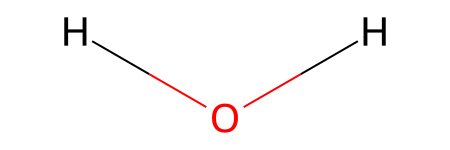

In [31]:
mol

In [27]:
smiles_list

['C([H])([H])([H])[H]',
 'N([H])([H])[H]',
 'O([H])[H]',
 'C(C[H])[H]',
 'C(N)[H]',
 'C(O)([H])[H]',
 'C(C([H])([H])[H])([H])([H])[H]',
 'C(O[H])([H])([H])[H]',
 'C(CC[H])([H])([H])[H]',
 'C(CN)([H])([H])[H]',
 'C(C(O)[H])([H])([H])[H]',
 'N(C(O)[H])([H])[H]',
 'C(C(C([H])([H])[H])([H])[H])([H])([H])[H]',
 'C(C(O[H])([H])[H])([H])([H])[H]',
 'C(OC([H])([H])[H])([H])([H])[H]',
 'C1([H])([H])C([H])([H])C1([H])[H]',
 'C1([H])([H])C([H])([H])O1',
 'C(C(C([H])([H])[H])O)([H])([H])[H]',
 'C(C(N([H])[H])O)([H])([H])[H]',
 'N(C(N([H])[H])O)([H])[H]',
 'C(C(C([H])([H])[H])(C([H])([H])[H])[H])([H])([H])[H]',
 'C(C(C([H])([H])[H])(O[H])[H])([H])([H])[H]',
 'C(CC[H])C[H]',
 'C(CN)C[H]',
 'NCCN',
 'OC(CC[H])[H]',
 'OC(CN)[H]',
 'OC(C(O)[H])[H]',
 'C(CCC([H])([H])[H])([H])([H])[H]',
 'C(C(CC[H])([H])[H])([H])([H])[H]',
 'C(C(CN)([H])[H])([H])([H])[H]',
 'N(C(CN)([H])[H])([H])[H]',
 'O(C(CC[H])([H])[H])[H]',
 'O(C(CN)([H])[H])[H]',
 'C(C(C(O)[H])([H])[H])([H])([H])[H]',
 'C(N(C(O)[H])[H])([H])([H])[H

In [5]:
data = data[0]
print("z:", data.z.shape)
print("edge_index:", data.edge_index.shape)
print("has edge_attr:", hasattr(data, "edge_attr"))
if hasattr(data, "edge_attr"):
    print("edge_attr shape:", data.edge_attr.shape)
    print("edge_attr example row:", data.edge_attr[0])


z: torch.Size([5])
edge_index: torch.Size([2, 8])
has edge_attr: True
edge_attr shape: torch.Size([8, 4])
edge_attr example row: tensor([1., 0., 0., 0.])


In [6]:
from rdkit import Chem

def pyg_to_rdkit_mol(data):
    """
    Build an RDKit Mol from PyG QM9 Data (z, edge_index, edge_attr if available).
    Assumes edge_index is directed; we convert to undirected unique bonds (u < v).
    If edge_attr exists and encodes bond type, we use it.
    """
    rw = Chem.RWMol()

    # add atoms
    for Z in data.z.tolist():
        rw.AddAtom(Chem.Atom(int(Z)))

    # decide how to interpret bond types
    use_edge_attr = hasattr(data, "edge_attr") and data.edge_attr is not None

    # bond type mapping (common convention: [single, double, triple, aromatic])
    def bondtype_from_attr(attr_row):
        # attr_row could be one-hot vector length 4
        # fallback: treat as single
        if len(attr_row) == 4:
            k = int(attr_row.argmax())
            return [Chem.rdchem.BondType.SINGLE,
                    Chem.rdchem.BondType.DOUBLE,
                    Chem.rdchem.BondType.TRIPLE,
                    Chem.rdchem.BondType.AROMATIC][k]
        return Chem.rdchem.BondType.SINGLE

    # build undirected edges
    ei = data.edge_index.cpu()
    edges = ei.t().tolist()

    seen = set()
    for e_idx, (u, v) in enumerate(edges):
        if u == v:
            continue
        a, b = (u, v) if u < v else (v, u)
        if (a, b) in seen:
            continue
        seen.add((a, b))

        if use_edge_attr:
            bt = bondtype_from_attr(data.edge_attr[e_idx].cpu())
        else:
            bt = Chem.rdchem.BondType.SINGLE

        # AddBond can throw if bond already exists; we avoided duplicates with `seen`
        rw.AddBond(int(a), int(b), bt)

    mol = rw.GetMol()

    # sanitize to make it a proper RDKit Mol
    try:
        Chem.SanitizeMol(mol)
    except Exception:
        # If sanitization fails, still return mol for substructure matching sometimes,
        # but SMARTS with valence constraints may fail.
        pass

    return mol


In [7]:
def find_func_groups_from_pyg(data, func_group_mol):
    mol = pyg_to_rdkit_mol(data)

    out = {}
    for fg, q in func_group_mol.items():
        matches = mol.GetSubstructMatches(q)
        if matches:
            out[fg] = matches
    return out


In [11]:
idx = 36
fgs = find_func_groups_from_pyg(data[idx], func_group_mol)
print(idx, data[idx].smiles)
print(fgs)


KeyError: 36